# Feed Forward Neural Network

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import gzip
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

First, we will import the **MNIST** dataset. We will be creating a Feed Forward Neural Network for it.

The dataset will be split in the following manner:
- 50,000 entries for __training__
- 10,000 entries for __validation__
- 10,000 entries for __test__

In [2]:
def get_labels(path):
    with gzip.open(path, 'rb') as data:
        labels = data.read()[8:]
        return np.frombuffer(labels, dtype=np.uint8)

def get_images(path):
    with gzip.open(path, 'rb') as data:
        _ = int.from_bytes(data.read(4), 'big')
        num_images = int.from_bytes(data.read(4), 'big')
        rows = int.from_bytes(data.read(4), 'big')
        cols = int.from_bytes(data.read(4), 'big')
        images = data.read()
        return np.frombuffer(images, dtype=np.uint8).reshape((num_images, rows, cols))

In [3]:
# first, load train-val
xtrain_val = get_images('data/train-images-idx3-ubyte.gz')
ytrain_val = get_labels('data/train-labels-idx1-ubyte.gz')

# then, load test
xtest = get_images('data/t10k-images-idx3-ubyte.gz')
ytest = get_labels('data/t10k-labels-idx1-ubyte.gz')

# split into 50k, 10k, 10k
xtrain = xtrain_val[:50000]
ytrain = ytrain_val[:50000]
xval = xtrain_val[50000:]
yval = ytrain_val[50000:]
# test is already 10k

We also need to flatten the 28x28 image.

In [4]:
xtrain = xtrain.reshape((xtrain.shape[0], -1)).astype(np.float32)
xval = xval.reshape((xval.shape[0], -1)).astype(np.float32)
xtest = xtest.reshape((xtest.shape[0], -1)).astype(np.float32)
ytrain = ytrain.reshape((ytrain.shape[0],))
yval = yval.reshape((yval.shape[0],))
ytest = ytest.reshape((ytest.shape[0],))

print(f"Training set: {xtrain.shape}, {ytrain.shape}")
print(f"Validation set: {xval.shape}, {yval.shape}")
print(f"Test set: {xtest.shape}, {ytest.shape}")

Training set: (50000, 784), (50000,)
Validation set: (10000, 784), (10000,)
Test set: (10000, 784), (10000,)


To ensure the validity of our dataset, let's try printing one of the entries

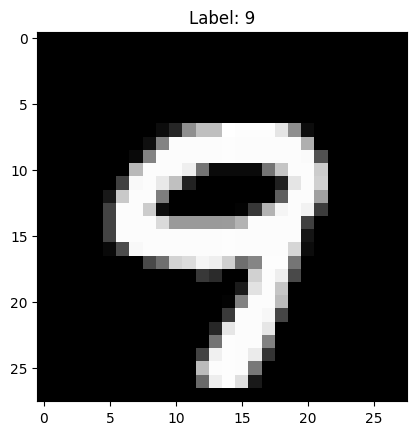

In [5]:
idx = np.random.randint(0, xtrain.shape[0])
plt.imshow(xtrain[idx].reshape((28, 28)), cmap='gray')
plt.title(f'Label: {ytrain[idx]}')
plt.show()

## Making the Network

We can kick it off by defining our network class, using PyTorch's `torch.nn` module and its `Sequential` model.

Our Feed Forward Network will have a forward pass implemented using a hidden layer, an activation function, an input layer (implicit), and an output layer.

We will use `Linear` layers and `ReLU` as our activation function.

In [6]:
model = nn.Sequential(
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

There are 3 layers in this model:
- Input (implicit) of 784 neurons
- Hidden layer of 128 neurons
- Output layer of 10 neeurons (10 classes)

### Optimizer

Now, to improve the model by reducing overfitting, we can add an optimizer. The optimizer will help update the weights with a fixed decay rate that will punish weights that the model is relying too much on.

In [7]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

### Loss Function

To measure the model's performance we need a metric that will determine the loss of the model's performance through its lifetime.

In [8]:
loss_fn = nn.CrossEntropyLoss()

Because this is a multiclass problem (we have 10 different classes in the pool), we can use `CrossEntropyLoss`. It uses a sigmoid function internally and will yield a probability for each class in the output.

## Training

## Training

We will manually train our model.

Our train function will do this each epoch (training iteration):
1. Reset the gradients (per mini-batch)
2. Train the model (forward pass on mini-batches)
3. Compute the loss (per mini-batch)
4. Compute the gradients (backward pass)
5. Update the weights using the optimizer (per mini-batch)
6. Evaluate the model with the validation set using the same loss function
7. Compute validation accuracy

In [9]:
def evaluate(model, loss_fn, xval, yval):
    model.eval()
    with torch.no_grad():
        val_outputs = model(torch.from_numpy(xval).float())
        val_loss = loss_fn(val_outputs, torch.from_numpy(yval).long())

        # accuracy
        preds = val_outputs.argmax(dim=1) # top probability
        acc = (preds == torch.from_numpy(yval).long()).float().mean()
    return val_loss.item(), acc.item()

def train(model, optimizer, loss_fn, xtrain, ytrain, xval, yval, epochs=10, batch_size=32, delta=0.005, patience=3):
    val_loss_history = []

    # for each epoch
    for epoch in range(epochs):
        # we train the model
        model.train()

        # loop over mini batches
        for i in range(0, len(xtrain), batch_size):
            batch_x = torch.from_numpy(xtrain[i:i+batch_size]).float()
            batch_y = torch.from_numpy(ytrain[i:i+batch_size]).long()

            # compute outputs to measure the loss (forward pass)
            outputs = model(batch_x)
            loss = loss_fn(outputs, batch_y)

            # reset the GRADIENTS to zero
            optimizer.zero_grad()

            # compute the GRADIENTS (backward pass)
            loss.backward()

            # update the WEIGHTS, as they were modified by the backward pass
            # this is what persists across iterations and epochs
            optimizer.step()

        # then we evaluate the model on the validation set
        # using torch.no_grad() to avoid computing gradients
        # and the loss_fn
        val_loss, accuracy = evaluate(model, loss_fn, xval, yval)
        val_loss_history.append(val_loss)

        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Val Loss: {val_loss:.4f}, Val Acc: {accuracy:.4f}')

        # early stopping
        # check if val_loss improved by at least delta over the last patience epochs
        if len(val_loss_history) > patience:
            # this is abs(loss(n-patience) - loss(n))
            loss_n_patience = val_loss_history[-patience-1]
            loss_n = val_loss_history[-1]
            current_delta =  abs(loss_n_patience - loss_n)
            if current_delta < delta and loss_n_patience >= loss_n:
                print(f"Early stopping at epoch {epoch+1}")
                break

## First Network

For the first network, we will choose the default hyperparameters/settings as a baseline to compare against:

-  Architecture: __3 layers__
   - Input Layer (784)
    - Hidden Layer (128 neurons)
   - Output Layer (10)
- Optimizer: `ADAM with learning rate 0.001`
- Loss Function: `Cross Entropy Loss`
- Epochs: `10`
- Batch Size: `32`
- Patience: `3`

In [10]:
model1 = nn.Sequential(
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)
optimizer = optim.Adam(model1.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()
epochs = 10
batch_size = 32

train(model1, optimizer, loss_fn, xtrain, ytrain, xval, yval, epochs, batch_size, patience=3)

C:\Users\PC\AppData\Local\Temp\ipykernel_32096\1811681131.py:23: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  batch_y = torch.from_numpy(ytrain[i:i+batch_size]).long()


Epoch 1/10, Loss: 0.2463, Val Loss: 0.2627, Val Acc: 0.9253
Epoch 2/10, Loss: 0.1990, Val Loss: 0.2325, Val Acc: 0.9363
Epoch 3/10, Loss: 0.2581, Val Loss: 0.2405, Val Acc: 0.9432
Epoch 4/10, Loss: 0.3005, Val Loss: 0.2589, Val Acc: 0.9419
Early stopping at epoch 4


## Second Network

- Architecture: **4 layers**
  - Input Layer (784)
  - Hidden Layer 1 (256 neurons)
  - Hidden Layer 2 (128 neurons)
  - Output Layer (10)
- Optimizer: `SGD with learning rate 0.00001`
- Loss Function: `Cross Entropy Loss`
- Epochs: `45`
- Batch Size: `64`
- Patience: `4`

In [11]:
model2 = nn.Sequential(
    nn.Linear(28*28, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)
optimizer = optim.SGD(model2.parameters(), lr=0.00001)
loss_fn = nn.CrossEntropyLoss()
epochs = 15
batch_size = 64

train(model2, optimizer, loss_fn, xtrain, ytrain, xval, yval, epochs, batch_size, patience=4)

Epoch 1/15, Loss: 1.9960, Val Loss: 1.7630, Val Acc: 0.5621
Epoch 2/15, Loss: 1.5511, Val Loss: 1.1543, Val Acc: 0.6891
Epoch 3/15, Loss: 1.3403, Val Loss: 0.9208, Val Acc: 0.7471
Epoch 4/15, Loss: 1.2053, Val Loss: 0.7933, Val Acc: 0.7774
Epoch 5/15, Loss: 1.1027, Val Loss: 0.7108, Val Acc: 0.7999
Epoch 6/15, Loss: 1.0171, Val Loss: 0.6518, Val Acc: 0.8149
Epoch 7/15, Loss: 0.9389, Val Loss: 0.6067, Val Acc: 0.8288
Epoch 8/15, Loss: 0.8682, Val Loss: 0.5707, Val Acc: 0.8386
Epoch 9/15, Loss: 0.8082, Val Loss: 0.5413, Val Acc: 0.8475
Epoch 10/15, Loss: 0.7509, Val Loss: 0.5166, Val Acc: 0.8534
Epoch 11/15, Loss: 0.6995, Val Loss: 0.4954, Val Acc: 0.8594
Epoch 12/15, Loss: 0.6569, Val Loss: 0.4769, Val Acc: 0.8650
Epoch 13/15, Loss: 0.6186, Val Loss: 0.4607, Val Acc: 0.8694
Epoch 14/15, Loss: 0.5825, Val Loss: 0.4463, Val Acc: 0.8730
Epoch 15/15, Loss: 0.5496, Val Loss: 0.4335, Val Acc: 0.8759


## Third Network

- Architecture: **5 layers**
  - Input Layer (784)
  - Hidden Layer 1 (512 neurons)
  - Hidden Layer 2 (256 neurons)
  - Hidden Layer 3 (128 neurons)
  - Output Layer (10)
- Optimizer: `Adam with learning rate 0.0003`
- Loss Function: `Cross Entropy Loss`
- Epochs: `20`
- Batch Size: `128`
- Delta: `0.004`

In [12]:
model3 = nn.Sequential(
    nn.Linear(28*28, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)
optimizer = optim.Adam(model3.parameters(), lr=0.0003)
loss_fn = nn.CrossEntropyLoss()
epochs = 20
batch_size = 128

train(model3, optimizer, loss_fn, xtrain, ytrain, xval, yval, epochs, batch_size, delta=0.004)

Epoch 1/20, Loss: 0.1590, Val Loss: 0.1282, Val Acc: 0.9619
Epoch 2/20, Loss: 0.0617, Val Loss: 0.1055, Val Acc: 0.9697
Epoch 3/20, Loss: 0.0168, Val Loss: 0.0995, Val Acc: 0.9719
Epoch 4/20, Loss: 0.0046, Val Loss: 0.0934, Val Acc: 0.9728
Epoch 5/20, Loss: 0.0146, Val Loss: 0.0950, Val Acc: 0.9761
Epoch 6/20, Loss: 0.0121, Val Loss: 0.1181, Val Acc: 0.9720
Epoch 7/20, Loss: 0.0506, Val Loss: 0.1137, Val Acc: 0.9742
Epoch 8/20, Loss: 0.0078, Val Loss: 0.1080, Val Acc: 0.9751
Epoch 9/20, Loss: 0.0173, Val Loss: 0.1109, Val Acc: 0.9757
Epoch 10/20, Loss: 0.0007, Val Loss: 0.1325, Val Acc: 0.9729
Epoch 11/20, Loss: 0.0035, Val Loss: 0.1393, Val Acc: 0.9736
Epoch 12/20, Loss: 0.0437, Val Loss: 0.1286, Val Acc: 0.9727
Epoch 13/20, Loss: 0.0029, Val Loss: 0.1323, Val Acc: 0.9746
Early stopping at epoch 13


## Best Model Evaluation on Test Set

Now that all three models have been trained, we evaluate all of them on the **test set** to compare their performance and identify the best one in terms of loss and accuracy.

In [13]:
loss_fn = nn.CrossEntropyLoss()

test_loss1, test_acc1 = evaluate(model1, loss_fn, xtest, ytest)
test_loss2, test_acc2 = evaluate(model2, loss_fn, xtest, ytest)
test_loss3, test_acc3 = evaluate(model3, loss_fn, xtest, ytest)

print("Test Set Results:")
print(f"Model 1 - Loss: {test_loss1:.4f}, Accuracy: {test_acc1:.4f}")
print(f"Model 2 - Loss: {test_loss2:.4f}, Accuracy: {test_acc2:.4f}")
print(f"Model 3 - Loss: {test_loss3:.4f}, Accuracy: {test_acc3:.4f}")

Test Set Results:
Model 1 - Loss: 0.2812, Accuracy: 0.9361
Model 2 - Loss: 0.4521, Accuracy: 0.8730
Model 3 - Loss: 0.1123, Accuracy: 0.9765


Then we pick the best model by Test Accuracy

In [14]:
models = [model1, model2, model3]
test_accs = [test_acc1, test_acc2, test_acc3]
test_losses = [test_loss1, test_loss2, test_loss3]
best_idx = test_accs.index(max(test_accs))
best_model = models[best_idx]

print(f"Best model: Model {best_idx + 1}")
print(f"Test Loss: {test_losses[best_idx]:.4f}")
print(f"Test Accuracy: {test_accs[best_idx]:.4f}")

Best model: Model 3
Test Loss: 0.1123
Test Accuracy: 0.9765


Finally, the best model out of the three created was __Model 3__. It's architecture was not only deeper (more layers), but it was also wider (more neurons).

### Classification Report

We need to make predictions to measure the model's performance. We will do this on the __test__ set, similar to how we did so on the __validation__ set in the `evaluation` function.

In [15]:
best_model.eval()
with torch.no_grad():
    # argmax because we want the best class
    y_pred = best_model(torch.from_numpy(xtest).float()).argmax(dim=1).numpy()

Then, we can compute the confusion matrix

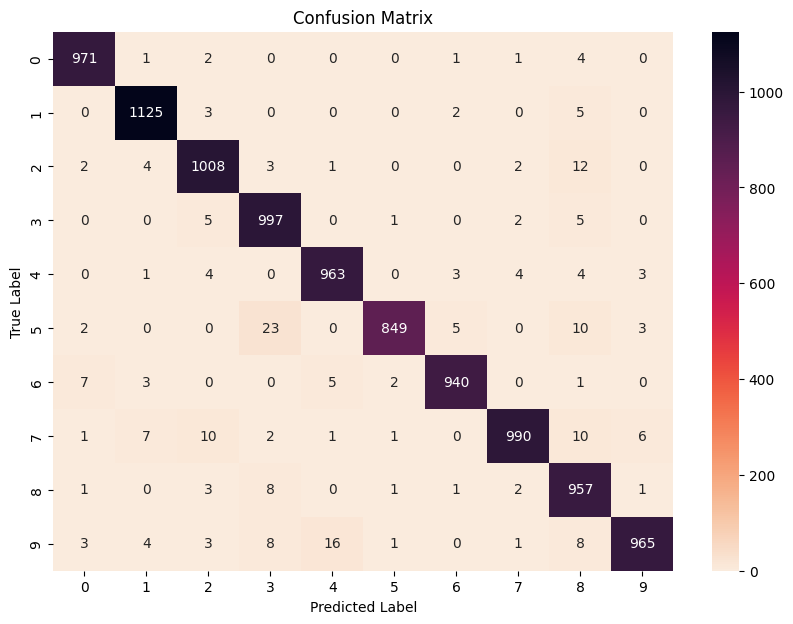

In [16]:
n_classes = 10 # there are 10 classes in MNIST
matrix = np.zeros((n_classes, n_classes), dtype=int) # make the matrix
for true, pred in zip(ytest, y_pred):
    matrix[true][pred] += 1 # then populate it by adding 1 to each x-y pair

# confusion matrices are heatmaps
plt.figure(figsize=(10, 7))
sns.heatmap(matrix, annot=True, fmt='d', cmap='rocket_r')
plt.xlabel('Predicted Label') #ytest
plt.ylabel('True Label') # y_pred
plt.title('Confusion Matrix')
plt.show()

Then, using the raw confusion matrix (the `n*n` matrix) we can compute the remaining scores:
- Accuracy (global)
- Recall (per class)
- Precision (per class)
- F1-Score (per class)

In [17]:
# global accuracy = correct predictions / total predictions
def accuracy(matrix):
    correct = 0
    total = 0
    
    # loop through all the rows of the matrix (true labels)
    for i in range(len(matrix)):
        # then loop through all predictions for that true label
        for j in range(len(matrix[i])):
            total += matrix[i][j] # add one to the prediction count
            if i == j: # and if it matches to the true label
                correct += matrix[i][j]

    return correct / total if total > 0 else 0.0

# class precision = true positives / (true positives + false positives)
def precision(matrix, class_idx):
    true_positives = matrix[class_idx][class_idx]
    
    false_positives = 0
    for i in range(len(matrix)):
        if i != class_idx:  # exclude true_positives
            false_positives += matrix[i][class_idx]

    denom = true_positives + false_positives
    return true_positives / denom if denom > 0 else 0.0

# class recall = true positives / (true positives + false negatives)
def recall(matrix, class_idx):
    true_positives = matrix[class_idx][class_idx]
    
    false_negatives = 0
    for j in range(len(matrix[class_idx])):
        if j != class_idx:  # exclude true_positives
            false_negatives += matrix[class_idx][j]

    denom = true_positives + false_negatives
    return true_positives / denom if denom > 0 else 0.0

# class F1 score = 2 * (precision * recall) / (precision + recall)
def f1(matrix, class_idx):
    p = precision(matrix, class_idx)
    r = recall(matrix, class_idx)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

First, the global accuracy

In [18]:
print(f"Global Accuracy: {accuracy(matrix):.4f}")

Global Accuracy: 0.9765


Then, per-class recall

In [19]:
recall_per_class = [recall(matrix, i) for i in range(n_classes)]
print("Recall per class:")
for i in range(len(recall_per_class)):
    print(f"- Class {i}: {recall_per_class[i]:.4f}")

Recall per class:
- Class 0: 0.9908
- Class 1: 0.9912
- Class 2: 0.9767
- Class 3: 0.9871
- Class 4: 0.9807
- Class 5: 0.9518
- Class 6: 0.9812
- Class 7: 0.9630
- Class 8: 0.9825
- Class 9: 0.9564


Then, per-class precision

In [20]:
precision_per_class = [precision(matrix, i) for i in range(n_classes)]
print("Precision per class:")
for i in range(len(precision_per_class)):
    print(f"- Class {i}: {precision_per_class[i]:.4f}")

Precision per class:
- Class 0: 0.9838
- Class 1: 0.9825
- Class 2: 0.9711
- Class 3: 0.9577
- Class 4: 0.9767
- Class 5: 0.9930
- Class 6: 0.9874
- Class 7: 0.9880
- Class 8: 0.9419
- Class 9: 0.9867


Then, per-class F1-score

In [21]:
f1_per_class = [f1(matrix, i) for i in range(n_classes)]
print("F1 Score per class:")
for i in range(len(f1_per_class)):
    print(f"- Class {i}: {f1_per_class[i]:.4f}")

F1 Score per class:
- Class 0: 0.9873
- Class 1: 0.9868
- Class 2: 0.9739
- Class 3: 0.9722
- Class 4: 0.9787
- Class 5: 0.9720
- Class 6: 0.9843
- Class 7: 0.9754
- Class 8: 0.9618
- Class 9: 0.9713


And a final report: (table generated with help of AI)

In [22]:
print("\nClassification Report:")
print(f"Global Accuracy: {accuracy(matrix):.4f}")
print(f"{'Class':<10} {'Precision':<10} {'Recall':<10} {'F1 Score':<10}")
for i in range(n_classes):
    print(f"{i:<10} {precision_per_class[i]:<10.4f} {recall_per_class[i]:<10.4f} {f1_per_class[i]:<10.4f}")


Classification Report:
Global Accuracy: 0.9765
Class      Precision  Recall     F1 Score  
0          0.9838     0.9908     0.9873    
1          0.9825     0.9912     0.9868    
2          0.9711     0.9767     0.9739    
3          0.9577     0.9871     0.9722    
4          0.9767     0.9807     0.9787    
5          0.9930     0.9518     0.9720    
6          0.9874     0.9812     0.9843    
7          0.9880     0.9630     0.9754    
8          0.9419     0.9825     0.9618    
9          0.9867     0.9564     0.9713    


The metrics for every class are very good across the board. Particularily, we had some false positives for class 3 (inferred from its precision) and fsome false negatives for class 8 (inferred from its recall). However, the overall model appeared to perform well, evidenced by the good F1-Score yields (balanced by both precision and recall).

This can be confirmed by looking at the confusion matrix above, which showed very little false negatives and false positives.

## Final Remarks (Reflexión)

It's to be expected that __Model 3__ was able to have a better performance than the other models, and it was quite surprising that it did so in less epochs.

The following can be inferred from the previous analysis:
- Hyperparameters and model configuration are the determining factor in its performance.
- An optimizer is almost imperative in the face of overfitting.
- With an optimizer, it's very important to tinker with the learning rate to penalize the model weights properly.
- Higher epochs doesn't equal better performance. Eventually, the model can plateau (as it did with all three models) or even degrade. This can be confirmed by the early stopper stopping some trainings because the model did not show any improvement.
- The number of hidden layers (depth) and their neurons (width) are of utmost importance when it comes to making a model. However, training time can vastly increase the wider and deeper a model is.

All in all, it's worth recognizing that tuning a model's hyperparameters and adjusting its configuration are what makes or breaks a good network. Particularily, it's paramount to understand the model behavior before making any changes, as sometimes we may have very distinct problems, and there is no one-size-fits-all solution. In the case of overfitting, maybe we need to have less neurons per layer, or introduce an optimizer to punish reliance on certain connections.

Finally, the best configuration chosen out of the trained models isn't necessarily the best for each case. It is only the best model for the current problem, but other phenomenon might require a different setting that could yield better results.